<a href="https://colab.research.google.com/github/pampato77/bigdata/blob/main/Solucion_reto_SC_63_Mariana_Escobar_Camacho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn import cluster
from sklearn.cluster import KMeans
from google.colab import drive

drive.mount('/content/drive')
# 4. Incluye las librerías y guardar el archivo en una variable llamada "data"
data = pd.read_csv('/content/drive/MyDrive/2025/Aprendizaje supervisado/Reto/bank_marketing.csv')

Mounted at /content/drive


In [ ]:
data.head(4)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,self-employed,married,tertiary,no,2666,no,no,cellular,10,nov,318,2,97,6,success,yes
1,29,unemployed,single,unknown,no,1584,no,no,cellular,6,sep,245,1,-1,0,unknown,yes
2,41,blue-collar,married,secondary,no,2152,yes,no,cellular,17,nov,369,1,-1,0,unknown,no
3,50,blue-collar,married,secondary,no,84,yes,no,cellular,17,jul,18,8,-1,0,unknown,no


In [ ]:
#Obtener la información de dicha base de datos que incluya numero de registros, el total de variables,
#el tipo de cada variable, la cantidad de datos perdidos de cada variables en caso de exista
# Se tiene 17 columnas y 9,000 datos los tipos de datos son entero y objeto, de los cuales
#inferimos que
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB


In [ ]:
data.nunique()
#Las variables categoricas son job, marital, education, default,
# housing, loan, contact, month, poutcome

,0
age,74
job,12
marital,3
education,4
default,2
balance,3476
housing,2
loan,2
contact,3
day,31


In [ ]:
X = data[['age','job', 'marital', 'education', 'default', 'balance','housing', 'loan', 'contact', 'day','month', 'duration', 'campaign','pdays', 'previous' , 'poutcome']]
Y = data['y']

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
dtypes: int64(7), object(9)
memory usage: 1.1+ MB


In [ ]:
Y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 9000 entries, 0 to 8999
Series name: y
Non-Null Count  Dtype 
--------------  ----- 
9000 non-null   object
dtypes: object(1)
memory usage: 70.4+ KB


In [ ]:
X['job'].value_counts()

,count
job,
management,1999
blue-collar,1688
technician,1485
admin.,1004
services,771
retired,594
self-employed,319
student,312
unemployed,290


In [ ]:
X['contact'].value_counts()

,count
contact,
cellular,6438
unknown,1982
telephone,580


In [ ]:
X['education'].value_counts()

,count
education,
secondary,4486
tertiary,2893
primary,1244
unknown,377


In [ ]:
# Transformación de variables categóricas de manera que cada nivel quede registrado con un entero
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ['job', 'marital', 'education', 'default','housing','loan','contact','month','poutcome']
X[cols] = X[cols].apply(LabelEncoder().fit_transform)
X.head()

/tmp/ipython-input-1937095693.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cols] = X[cols].apply(LabelEncoder().fit_transform)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,31,6,1,2,0,2666,0,0,0,10,9,318,2,97,6,2
1,29,10,2,3,0,1584,0,0,0,6,11,245,1,-1,0,3
2,41,1,1,1,0,2152,1,0,0,17,9,369,1,-1,0,3
3,50,1,1,1,0,84,1,0,0,17,5,18,8,-1,0,3
4,40,0,1,1,0,0,0,0,0,28,5,496,2,182,11,2


In [ ]:
def fun2(X):
return (X[''] - np.mean(X[])) / np.std(X[])

In [ ]:
Y.value_counts()
#De donde se determina que hay 3,787 creditos aprobados y 5,213 que no fueron aprobados.

,count
y,
no,5213
yes,3787


In [ ]:
#9. Particiona los datos en los conjuntos de entrenamiento, validación y prueba en 60%, 20% y 20%, respectivamente.
from sklearn.model_selection import train_test_split

x_train_validation, x_test, y_train_validation, y_test = \
train_test_split(X, Y, test_size=.20)

x_train, x_validation, y_train, y_validation = \
train_test_split(x_train_validation, y_train_validation, test_size=0.250)

In [ ]:
print("Dimensión X_train_set:", x_train.shape)
print("Dimensión X_validation_set:\t", x_validation.shape)
print("Dimensión X_test_set:\t\t", x_test.shape)
print("\nDimensión Y_train:\t\t", y_train.shape)
print("Dimensión Y_validation:\t\t", y_validation.shape)
print("Dimensión Y_test:\t\t", y_test.shape)

Dimensión X_train_set: (5400, 16)
Dimensión X_validation_set:	 (1800, 16)
Dimensión X_test_set:		 (1800, 16)

Dimensión Y_train:		 (5400,)
Dimensión Y_validation:		 (1800,)
Dimensión Y_test:		 (1800,)


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression( C=1.0, solver='newton-cg')

modelo_RL = clf.fit( x_train, y_train )

print("Regresión Logística:\nExactitud (accuracy) con el conjunto de Validación = ", modelo_RL.score(x_validation, y_validation))

#Se obtuvo 79% de exactitud en tu primera aproximación del modelo de regresión logística
#con el conjunto de validación.

Regresión Logística:
Exactitud (accuracy) con el conjunto de Validación =  0.7944444444444444


In [ ]:
#Matriz de confusión
from sklearn.metrics import confusion_matrix
pr = modelo_RL.predict(x_validation)
confusion_matrix(y_validation, pr)

array([[898, 161],
       [209, 532]])

In [ ]:
#11. Aplica el modelo Red Neuronal en el conjunto de entrenamiento. Valida el modelo con las predicciones del conjunto de validación y su matriz de confusión.
#Ajusta los parámetros del modelo hasta obtener tu mejor modelo, entre ellos el número de neuronas y capas  ocultas.
from sklearn.neural_network import MLPClassifier
modelo_NN = MLPClassifier(hidden_layer_sizes=(15, 4), max_iter=3787)
modelo_NN.fit(x_train, y_train)

MLPClassifier(hidden_layer_sizes=(15, 4), max_iter=3787)

In [ ]:
print(modelo_NN.score(x_validation, y_validation))

0.7166666666666667


In [ ]:
#Matriz de confusion
print(confusion_matrix(y_test, pr))

[[633 413]
 [474 280]]


In [ ]:
#12. Seleccionar modelo encontrado
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000,
                           n_features=20,
                           flip_y=0.2,
                           random_state=17)

print(X.shape, y.shape)

(1000, 20) (1000,)


In [ ]:
X[0:2,:]

array([[ 0.30720761,  0.78851574,  1.57775826, -0.83782462, -1.9092439 ,
        -0.52486904, -0.59594565, -1.35986902,  1.10949158, -1.87040312,
         2.0555414 , -0.1644116 ,  0.05467622, -1.00918284, -1.89062424,
         0.27800919,  0.30241122, -0.38344902, -0.57919446, -1.37604018],
       [-1.53627982,  0.12338025,  0.07355866,  0.09005639, -0.58258365,
         0.32100129,  2.6984525 ,  0.31212436,  0.29067048,  1.77439268,
        -1.39129642,  0.22318237,  2.34097438, -1.30102918,  1.07591658,
         0.38101488,  0.3963937 ,  0.87694313,  0.29912412,  2.42462292]])

In [ ]:
y[0:10]

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.6,
                                                    random_state=11)


print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(600, 20) (400, 20) (600,) (400,)


In [ ]:
neuronas = [i for i in range(1, 50, 5)]

print(neuronas)

[1, 6, 11, 16, 21, 26, 31, 36, 41, 46]


In [ ]:
from sklearn.neural_network import MLPClassifier
import numpy as np

train_scores, test_scores = list(), list()
train_errors, test_errors = list(), list()

for i in neuronas:

  model = MLPClassifier(hidden_layer_sizes=(i,i),
                        max_iter=3000,
                        alpha=50,
                        random_state=42)

  model.fit(X_train, y_train)


  # Predicciones y métricas con el conjunto de entrenamiento:
  train_yhat = model.predict(X_train)

  train_loss =  np.mean(abs(y_train - train_yhat))
  train_errors.append(train_loss)

  train_acc = 1 - train_loss
  train_scores.append(train_acc)



  # Predicciones y métricas con el conjunto de prueba:
  test_yhat = model.predict(X_test)

  test_loss = np.mean(abs(y_test - test_yhat))
  test_errors.append(test_loss)

  test_acc = 1 - test_loss
  test_scores.append(test_acc)



  # evolución de las métricas durante el entrenamiento ...
  print('> %d...\t trainacc: %.3f, testacc: %.3f, trainloss: %.3f, testloss: %.3f'
        % (i, train_acc, test_acc, train_loss, test_loss))

> 1...	 trainacc: 0.518, testacc: 0.500, trainloss: 0.482, testloss: 0.500
> 6...	 trainacc: 0.518, testacc: 0.500, trainloss: 0.482, testloss: 0.500
> 11...	 trainacc: 0.518, testacc: 0.500, trainloss: 0.482, testloss: 0.500
> 16...	 trainacc: 0.518, testacc: 0.500, trainloss: 0.482, testloss: 0.500
> 21...	 trainacc: 0.518, testacc: 0.500, trainloss: 0.482, testloss: 0.500
> 26...	 trainacc: 0.518, testacc: 0.500, trainloss: 0.482, testloss: 0.500
> 31...	 trainacc: 0.518, testacc: 0.500, trainloss: 0.482, testloss: 0.500
> 36...	 trainacc: 0.518, testacc: 0.500, trainloss: 0.482, testloss: 0.500
> 41...	 trainacc: 0.518, testacc: 0.500, trainloss: 0.482, testloss: 0.500
> 46...	 trainacc: 0.518, testacc: 0.500, trainloss: 0.482, testloss: 0.500


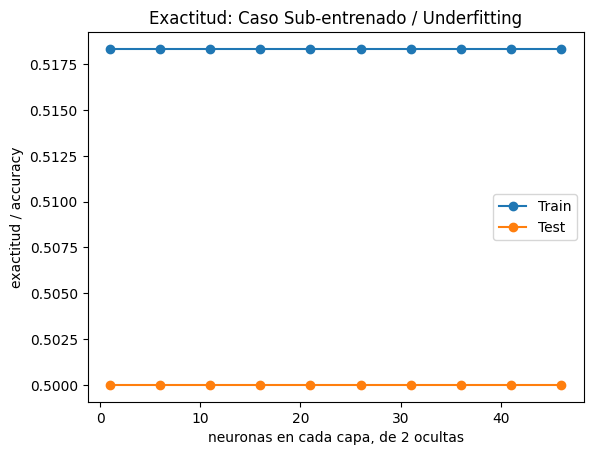

In [ ]:
import matplotlib.pyplot as plt

plt.plot(neuronas, train_scores, '-o', label='Train')
plt.plot(neuronas, test_scores, '-o', label='Test')
plt.legend()
plt.title('Exactitud: Caso Sub-entrenado / Underfitting')
plt.xlabel('neuronas en cada capa, de 2 ocultas')
plt.ylabel('exactitud / accuracy')
plt.show()

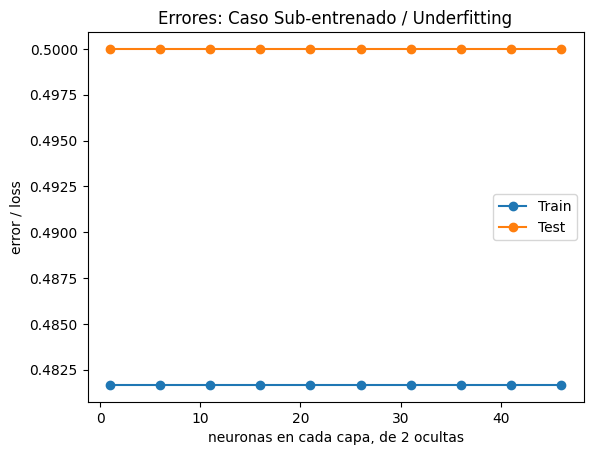

In [ ]:
plt.plot(neuronas, train_errors, '-o', label='Train')
plt.plot(neuronas, test_errors, '-o', label='Test')
plt.legend()
plt.title('Errores: Caso Sub-entrenado / Underfitting')
plt.xlabel('neuronas en cada capa, de 2 ocultas')
plt.ylabel('error / loss')
plt.show()

In [ ]:
#Sobreentrenamiento
X, y = make_classification(n_samples=1000, n_features=20, flip_y=0.3, random_state=17)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=11)
neuronas = [i for i in range(1, 50, 5)]

In [ ]:
train_scores, test_scores = list(), list()
train_errors, test_errors = list(), list()

for i in neuronas:

  model = MLPClassifier(hidden_layer_sizes=(i,i),
                        max_iter=3000,
                        alpha=0.15,
                        random_state=42)

  model.fit(X_train, y_train)

  # TRAIN set
  train_yhat = model.predict(X_train)

  train_loss = np.mean(abs(y_train - train_yhat))
  train_errors.append(train_loss)

  train_acc = 1 - train_loss
  train_scores.append(train_acc)


  # TEST set
  test_yhat = model.predict(X_test)

  test_loss =  np.mean(abs(y_test - test_yhat))
  test_errors.append(test_loss)

  test_acc = 1 - test_loss
  test_scores.append(test_acc)


  # progreso de las épocas del entrenamiento ...
  print('>%d, train: %.3f, test: %.3f, losstrain: %.3f, losstest: %.3f' % (i, train_acc, test_acc, train_loss, test_loss))

>1, train: 0.520, test: 0.515, losstrain: 0.480, losstest: 0.485
>6, train: 0.833, test: 0.740, losstrain: 0.168, losstest: 0.260
>11, train: 0.921, test: 0.675, losstrain: 0.079, losstest: 0.325
>16, train: 0.995, test: 0.715, losstrain: 0.005, losstest: 0.285
>21, train: 1.000, test: 0.675, losstrain: 0.000, losstest: 0.325
>26, train: 1.000, test: 0.690, losstrain: 0.000, losstest: 0.310
>31, train: 1.000, test: 0.710, losstrain: 0.000, losstest: 0.290
>36, train: 1.000, test: 0.700, losstrain: 0.000, losstest: 0.300
>41, train: 1.000, test: 0.690, losstrain: 0.000, losstest: 0.310
>46, train: 1.000, test: 0.705, losstrain: 0.000, losstest: 0.295


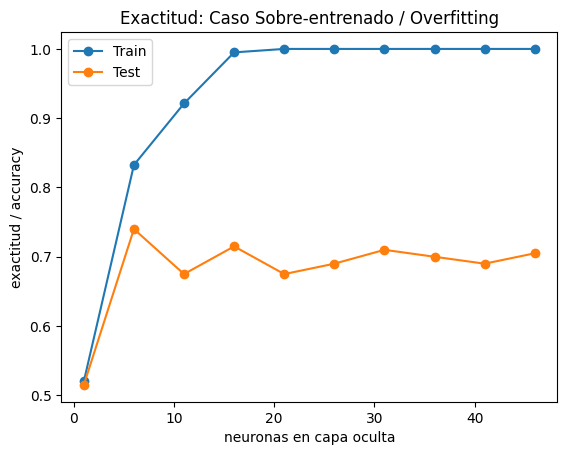

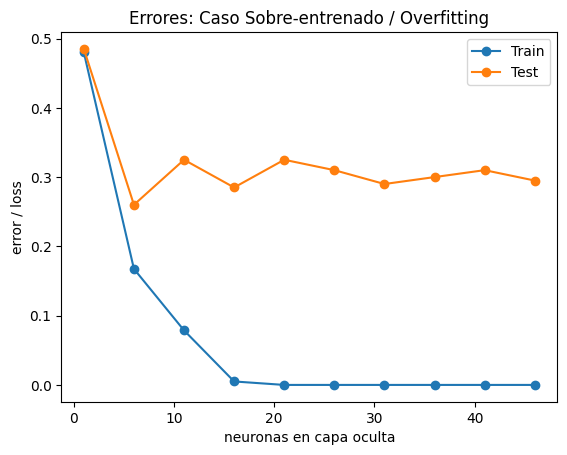

In [ ]:
import matplotlib.pyplot as plt

plt.plot(neuronas, train_scores, '-o', label='Train')
plt.plot(neuronas, test_scores, '-o', label='Test')
plt.legend()
plt.title('Exactitud: Caso Sobre-entrenado / Overfitting')
plt.xlabel('neuronas en capa oculta')
plt.ylabel('exactitud / accuracy')
plt.show()

plt.plot(neuronas, train_errors, '-o', label='Train')
plt.plot(neuronas, test_errors, '-o', label='Test')
plt.legend()
plt.title('Errores: Caso Sobre-entrenado / Overfitting')
plt.xlabel('neuronas en capa oculta')
plt.ylabel('error / loss')
plt.show()

In [ ]:
#Mejoras del ajuste
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X, y = make_classification(n_samples=10000,
n_features=20,
flip_y=0.2,
random_state=17)
X_train, X_test, y_train, y_test = train_test_split(X, y,
train_size=0.6,
random_state=11)

neuronas = [i for i in range(1, 50, 5)]

In [ ]:
model = MLPClassifier(hidden_layer_sizes=(i,i),
max_iter=1000,
alpha=0.7,
random_state=42)

In [ ]:
#Matriz de confusión
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer( return_X_y=True)
print(X.shape, y.shape)

(569, 30) (569,)


In [ ]:
print('Porcentaje creditos: %.1f' % (100 * sum(y) / y.shape[0]))
print('Porcentaje creditos: %.1f' % (100 * (1 - sum(y) / y.shape[0])))

Porcentaje creditos: 62.7
Porcentaje creditos: 37.3


In [ ]:
model = MLPClassifier(hidden_layer_sizes=(15),
max_iter=1000,
alpha=1.,
random_state=42)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.87275